# Exploración de los datos

## Configuraciones

In [1]:
import os
import numpy as np
import polars as pl
import scipy
from scipy.stats import entropy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
BASE_DIR = "../"
DATA_DIR = os.path.join(BASE_DIR, "data")
RAW_DATA_DIR = os.path.join(DATA_DIR, "raw")

## Vistazo inicial de los datos


In [3]:
files = os.listdir(RAW_DATA_DIR)[0]

In [4]:
raw_data = pl.read_parquet(os.path.join(RAW_DATA_DIR, files))

In [5]:
raw_data = raw_data.with_columns(pl.col("transaction_amount").cast(pl.Float64))

In [7]:
raw_data.describe()

statistic,merchant_id,_id,subsidiary,transaction_date,account_number,user_id,transaction_amount,transaction_type
str,str,str,str,str,str,str,f64,str
"""count""","""10758418""","""10758418""","""10758418""","""10758418""","""10758418""","""10758418""",1.0758418e7,"""10758418"""
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,"""0"""
"""mean""",null,null,null,"""2021-06-26 22:11:04.331519""",null,null,191.397399,null
"""std""",null,null,null,null,null,null,240.863288,null
"""min""","""075d178871d8d48502bf1f54887e52…","""000000c00a3d728b6b5c1580b48169…","""00015fd77a0f4d869bea31bb7244e3…","""2021-01-01 00:01:13""","""00000f81a1d5583a06a5cb7f4a1cbc…","""000002373d5835d0e53b7872242407…",5.944455,"""CREDITO"""
"""25%""",null,null,null,"""2021-03-30 18:20:05""",null,null,35.66673,null
"""50%""",null,null,null,"""2021-07-03 15:45:11""",null,null,107.00019,null
"""75%""",null,null,null,"""2021-09-22 18:09:18""",null,null,237.7782,null
"""max""","""838a8fa992a4aa2fb5a0cf8b15b637…","""ffffffe2449ec9564ed29c4a337969…","""ffffb61b4c0d1f409bcb747eec48fe…","""2021-11-30 23:59:49""","""fffffe2a4fc846166ad89e0c266773…","""ffffef81146ce1d4f4b5cdda9617cf…",4624.786,"""DEBITO"""


## Datos nulos

In [6]:
raw_data.null_count()

merchant_id,_id,subsidiary,transaction_date,account_number,user_id,transaction_amount,transaction_type
u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0


## Datos Duplicados

In [7]:
raw_data.is_duplicated().sum()

8

In [8]:
raw_data = raw_data.unique()

## Análisis Univariado

### transaction_amount

In [9]:
# Estadísticas descriptivas de transaction_amount
raw_data["transaction_amount"].describe()

statistic,value
str,f64
"""count""",1.0758414e7
"""null_count""",0.0
"""mean""",191.397356
"""std""",240.863281
"""min""",5.944455
"""25%""",35.66673
"""50%""",107.00019
"""75%""",237.7782
"""max""",4624.786


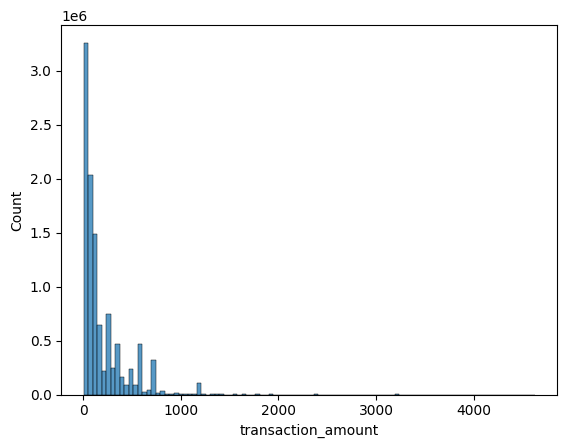

In [10]:
# Histograma de transaction_amount
sns.histplot(x=raw_data["transaction_amount"], bins=100)
plt.show()

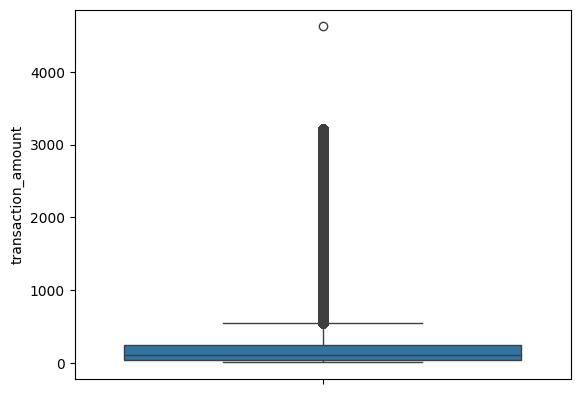

In [11]:
# Boxplot de transaction_amount
sns.boxplot(y=raw_data["transaction_amount"])
plt.show()

El monto pagado tiene una media de 191.3 y una desviación estándar de 240.8; una desviación estándar tan grande, mayor que la media, nos muestra la alta volatidad que tienen los montos en las transacciones. También vemos que cerca del 50% de las transacciones son <= 107; cerca del 75% son <= a 237 y el valor más alto ronda los 4.624. De nuevo, vemos la alta variación que hay en los valores y que hay un claro sesgo hacia muchas transacciones pequeñas y pocas grandes, un comportamiento normal.


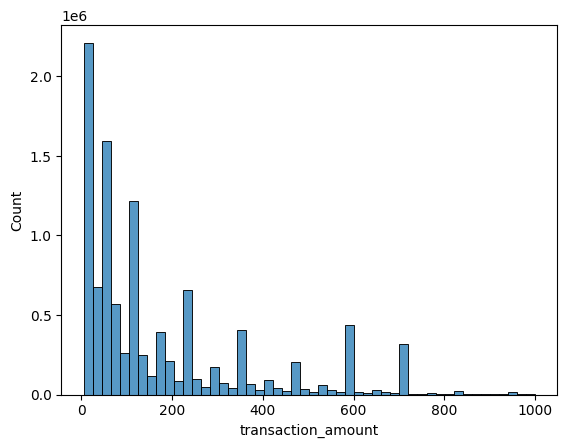

In [12]:
# Histograma de transaction_amount
sns.histplot(
    x=raw_data.filter(pl.col("transaction_amount") <= 1000)["transaction_amount"],
    bins=50,
)
plt.show()

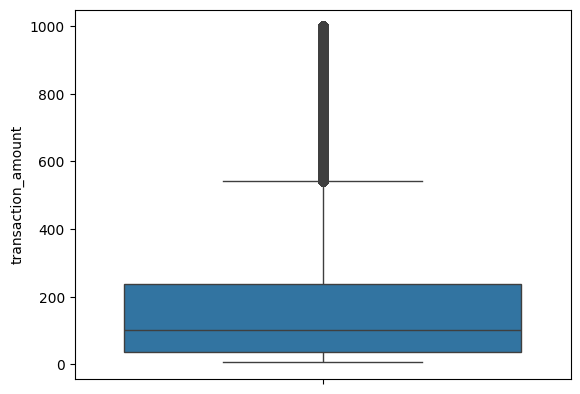

In [13]:
# Boxplot de transaction_amount
sns.boxplot(
    y=raw_data.filter(pl.col("transaction_amount") <= 1000)["transaction_amount"]
)
plt.show()

Dados los gráficos, intuyo que la mayoría de los datos deben ser <= a 700; también hay algunos picos marcados, que pueden representar valores muy exactos: 20, 60, 120, 600, 700. Vemos que a partir de cerca de 580 se comienzan a considerar transacciones atípicas (respecto a los rangos intercuartiles)


### transacion_date

In [14]:
raw_data = raw_data.with_columns(
    [
        pl.col("transaction_date").dt.hour().alias("hour"),
        pl.col("transaction_date")
        .dt.weekday()
        .alias("day_of_week"),  # Lunes=1, Domingo=7
        pl.col("transaction_date").dt.month().alias("month"),
    ]
)

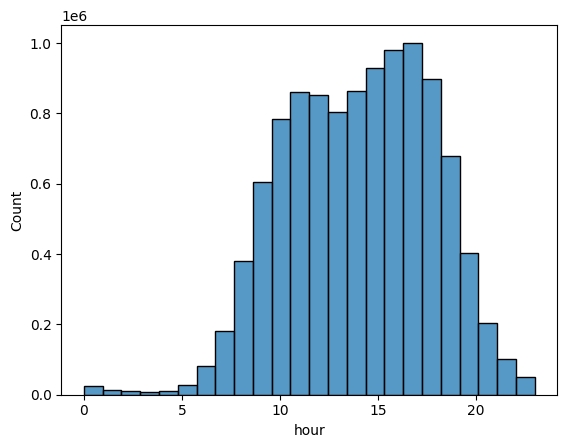

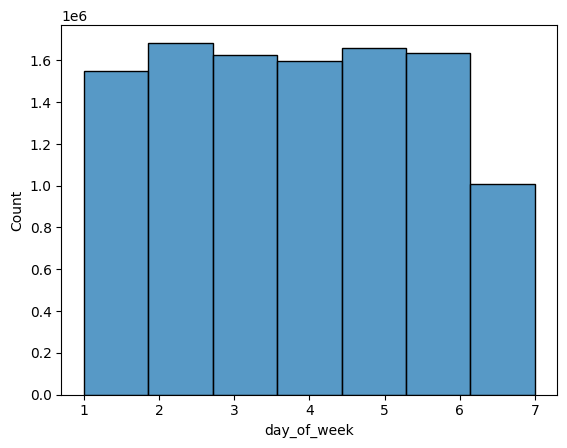

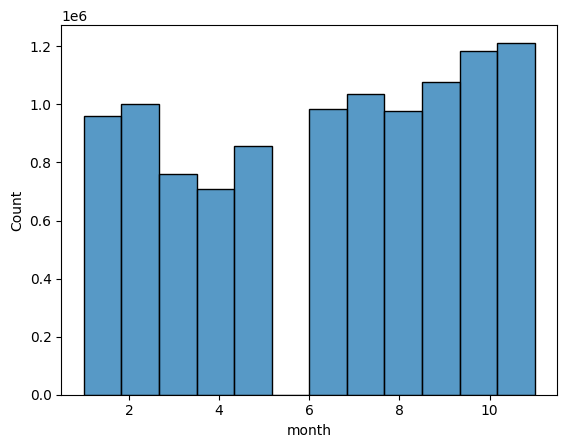

In [15]:
# Mostrar estadísticas por hora
sns.histplot(x=raw_data["hour"], bins=24)
plt.show()

# Mostrar estadísticas por día de la semana
sns.histplot(x=raw_data["day_of_week"], bins=7)
plt.show()

# Mostrar estadísticas por mes
sns.histplot(x=raw_data["month"], bins=12)
plt.show()

La mayoría de transacciones se producen entre las 8am y las 7pm, con mayor volumen entre las 2pm y 5pm, con pico a las 5pm, hora en la que las personas suelen terminar de laborar. Respecto al día de la semana, la única diferencia es que los domingos son los días con menos transacciones, pero durante el resto de la semana se mantiene un nivel similar.
Finalmente, respecto a los meses, se evidencia que desde septiembre hasta enero las transacciones suben hasta febrero y luego se reducen en cantidad hasta que en mayo comienzan a subir nuevamente.

### transaction_type


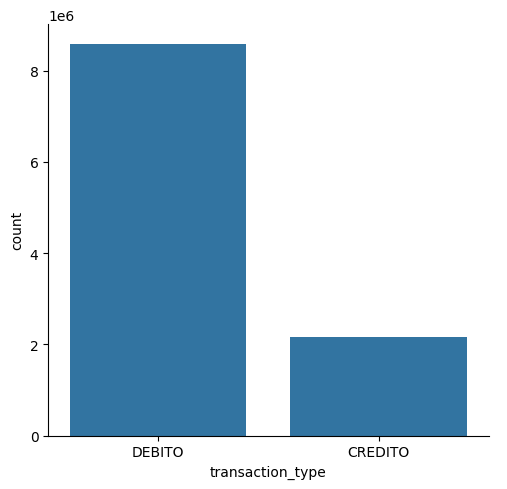

In [16]:
# catplot de transaction_type
sns.catplot(x="transaction_type", data=raw_data, kind="count")
plt.show()

In [17]:
raw_data.group_by("transaction_type").agg(pl.count().alias("count"))

C:\Users\alexg\AppData\Local\Temp\ipykernel_21136\3543596749.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  raw_data.group_by("transaction_type").agg(pl.count().alias("count"))


transaction_type,count
str,u32
"""DEBITO""",8591289
"""CREDITO""",2167125


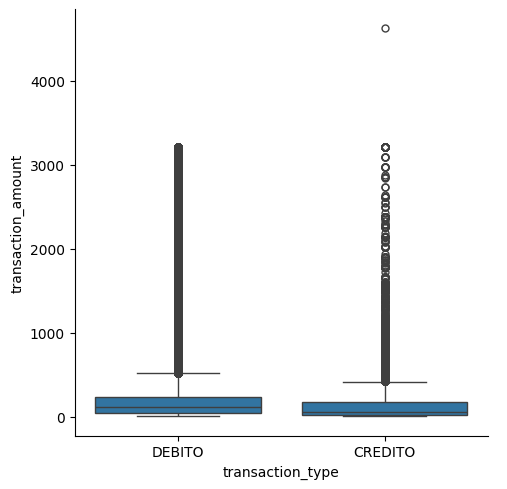

In [18]:
# catplot de transaction_type por transaction_amount
sns.catplot(x="transaction_type", y="transaction_amount", data=raw_data, kind="box")
plt.show()

Evidenciamos que se produce una mayor cantidad de transacciones con débito (casi el 80%) y también que la distribución de los montos entre crédito y débito es similar en montos pequeños, pero en débito, al tener mayor registros, se evidencia valores más altos

## Análisis Multivariado

### Transacciones múltiple mismo usuario y mismo comercio

In [19]:
def calculate_amount_entropy(amounts) -> float:
    # Convertir Series de Polars a lista de Python si es necesario
    if hasattr(amounts, "to_list"):  # Es un Series de Polars
        amounts_list = amounts.to_list()
    else:  # Ya es una lista de Python
        amounts_list = amounts

    if not amounts_list:  # Ahora podemos usar if not con una lista
        return 0.0

    value_counts = pd.Series(amounts_list).value_counts(normalize=True)
    return entropy(value_counts)

In [20]:
calculate_amount_entropy_pl = (
    pl.col("transaction_amount")
    .map_batches(lambda s: [calculate_amount_entropy(val) for val in s])
    .alias("amount_entropy")
)

In [21]:
# GroupBy con ventana temporal y agregaciones para "candidate groups"
candidate_groups = (
    raw_data.sort("transaction_date")
    .group_by_dynamic(
        index_column="transaction_date",
        every="24h",
        by=["user_id", "merchant_id", "transaction_type"],  # Agrupar por estas claves
    )
    .agg(
        [
            pl.count().alias("transaction_count"),
            pl.col("transaction_amount").sum().alias("total_group_amount"),
            pl.col("transaction_amount").std().alias("amount_stdev"),
            pl.col("transaction_amount").median().alias("amount_median"),
            pl.col("transaction_amount").min().alias("amount_min"),
            pl.col("transaction_amount").max().alias("amount_max"),
            (
                pl.col("transaction_amount").max() - pl.col("transaction_amount").min()
            ).alias("amount_range"),
            pl.col("transaction_date").max().alias("last_transaction_date"),
            pl.col("transaction_date").min().alias("first_transaction_date"),
            (
                (
                    pl.col("transaction_date").max() - pl.col("transaction_date").min()
                ).dt.total_minutes()
            ).alias("time_span_minutes"),
            # Para calcular avg_time_delta y features de uniformidad de montos:
            pl.col("transaction_amount").implode().alias("all_amounts_in_group"),
            pl.col("transaction_date").implode().alias("all_dates_in_group"),
        ]
    )
    .filter(
        pl.col("transaction_count")
        >= 3  # Considerar solo grupos con 3 o más transacciones
    )
    .with_columns(
        [
            # Coeficiente de Variación: stdev / mean
            (
                pl.col("amount_stdev")
                / pl.col("total_group_amount")
                * pl.col("transaction_count")
            ).alias("amount_coeff_of_variation"),
            # Entropía de los Montos (usando la UDF)
            pl.col("all_amounts_in_group")
            .map_elements(calculate_amount_entropy)
            .alias("amount_entropy"),  # Cambiado de .apply() a .map_elements()
        ]
    )
    .drop(["all_amounts_in_group", "all_dates_in_group"])
)  # Limpiar columnas auxiliares

C:\Users\alexg\AppData\Local\Temp\ipykernel_21136\2841248965.py:2: DeprecationWarning: the argument `by` for `DataFrame.group_by_dynamic` is deprecated. It was renamed to `group_by` in version 0.20.14.
  candidate_groups = raw_data.sort("transaction_date").group_by_dynamic(
C:\Users\alexg\AppData\Local\Temp\ipykernel_21136\2841248965.py:7: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("transaction_count"),
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.


In [22]:
candidate_groups.sort("transaction_count", descending=True).head()

user_id,merchant_id,transaction_type,transaction_date,transaction_count,total_group_amount,amount_stdev,amount_median,amount_min,amount_max,amount_range,last_transaction_date,first_transaction_date,time_span_minutes,amount_coeff_of_variation,amount_entropy
str,str,str,datetime[ns],u32,f64,f64,f64,f64,f64,f64,datetime[ns],datetime[ns],i64,f64,f64
"""71aa1651d9adc0b226107084fba3d7…","""838a8fa992a4aa2fb5a0cf8b15b637…","""CREDITO""",2021-02-07 00:00:00,188,1125.632489,0.432782,5.955155,5.944455,11.88891,5.944455,2021-02-07 19:15:22,2021-02-07 08:34:09,641,0.072282,3.068316
"""e77fc30bb3bec8bf45a35b535b2920…","""838a8fa992a4aa2fb5a0cf8b15b637…","""CREDITO""",2021-01-24 00:00:00,129,846.760272,5.526389,5.9456439,5.944455,65.579228,59.634773,2021-01-24 21:47:34,2021-01-24 15:14:34,393,0.84192,1.451509
"""6774dce23328e22fbe1884d53ad728…","""838a8fa992a4aa2fb5a0cf8b15b637…","""DEBITO""",2021-02-06 00:00:00,122,757.323568,0.495579,5.944455,5.944455,7.133346,1.188891,2021-02-06 19:50:26,2021-02-06 11:39:12,491,0.079835,0.528563
"""5ed6b358c9e7f53f343e5f36bffeec…","""838a8fa992a4aa2fb5a0cf8b15b637…","""CREDITO""",2021-02-10 00:00:00,111,788.472512,1.244079,7.133346,5.944455,8.916683,2.972227,2021-02-10 19:04:32,2021-02-10 10:04:52,539,0.17514,1.253015
"""01c2e0350f7d77f4084502861b4989…","""838a8fa992a4aa2fb5a0cf8b15b637…","""DEBITO""",2021-01-31 00:00:00,100,594.677335,0.000961,5.946833,5.9456439,5.948022,0.002378,2021-01-31 22:26:01,2021-01-31 08:21:18,844,0.000162,1.096067


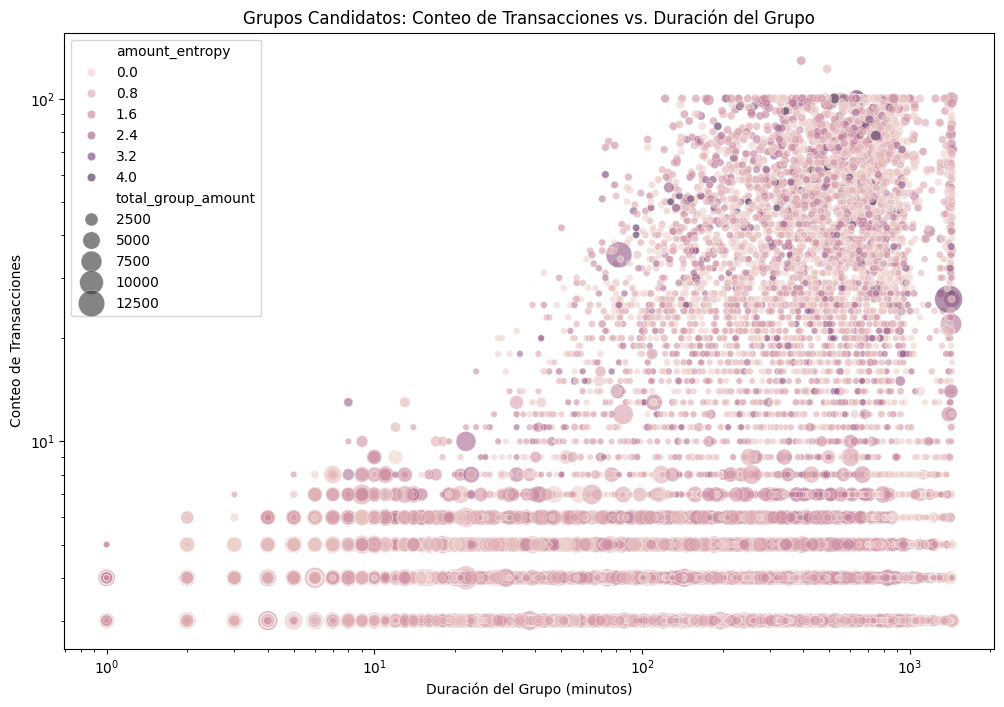

In [23]:
if candidate_groups.height > 100000:
    plot_df = candidate_groups.sample(n=100000).to_pandas()
else:
    plot_df = candidate_groups.to_pandas()

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="time_span_minutes",
    y="transaction_count",
    data=plot_df,
    alpha=0.6,
    hue="amount_entropy",
    size="total_group_amount",
    sizes=(20, 400),
)
plt.title("Grupos Candidatos: Conteo de Transacciones vs. Duración del Grupo")
plt.xlabel("Duración del Grupo (minutos)")
plt.ylabel("Conteo de Transacciones")
plt.xscale("log")  # Escala logarítmica para ver dispersión
plt.yscale("log")
plt.show()

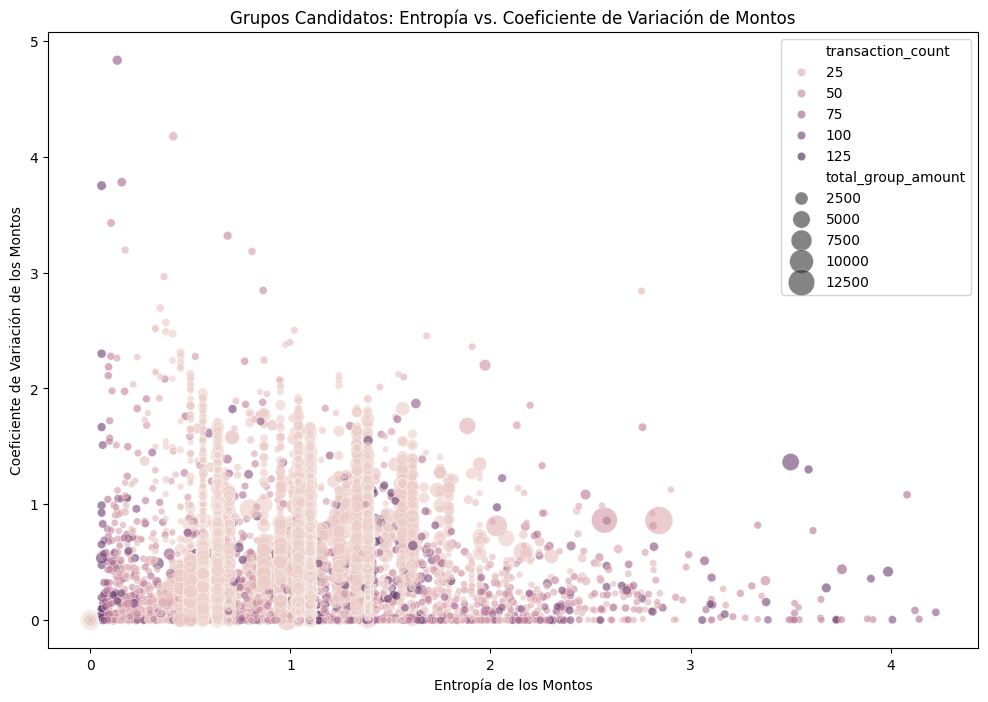

In [24]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="amount_entropy",
    y="amount_coeff_of_variation",
    data=plot_df,
    alpha=0.6,
    hue="transaction_count",
    size="total_group_amount",
    sizes=(20, 400),
)
plt.title("Grupos Candidatos: Entropía vs. Coeficiente de Variación de Montos")
plt.xlabel("Entropía de los Montos")
plt.ylabel("Coeficiente de Variación de los Montos")
plt.show()

Esta hipótesis consiste en verificar las transacciones múltiples del mismo usuario y mismo comercio en poco tiempo, ya que el comportamiento de fraccionamiento se manifiesta precisamente como una ráfaga de transacciones que comparten las mismas características dentro de una ventana temporal estrecha.

La mayoría de los grupos tendrán 1 o 2 transacciones. Un usuario típico no va a realizar 10 o 20 transacciones al mismo comercio en un solo día, a menos que sea un caso muy específico (como una feria). Grupos con alto transaction_count en el mismo día, para el mismo merchant_id y transaction_type son sospechosos.

Si un usuario hace varias compras legítimas en un comercio (por ejemplo, en una tienda), podría ser que realice varias transacciones con un time_span_minutes más amplio ( visita por la mañana y otra por la tarde), o bien, si son muy seguidas, quizás con el mismo merchant_id pero diferentes subsidiary si va a distintas cajas o departamentos. Sería sospechoso grupos con un transaction_count alto y un time_span_minutes muy corto (30 minutos a unas pocas horas). Esto sugiere una actividad concentrada y rápida para evadir un límite o una detección.


Si hay muchas transacciones legítimas en poco tiempo, los transaction_amount dentro del grupo probablemente serán variados. Compras de 10, 8, 35, etc. Esto resultará en una entropía de montos (amount_entropy) relativamente alta y un coeficiente de variación (amount_coeff_of_variation) más alto. Sería sospechoso si los montos dentro del grupo tienden a ser muy similares o idénticos ($500, $500, $500). Esto se reflejará en una entropía de montos (amount_entropy) muy baja (cercana a cero) y un coeficiente de variación (amount_coeff_of_variation) muy bajo (cercano a cero). Este es un indicador clave para diferenciar el fraccionamiento de una ráfaga legítima. Además, también es importante observar si muchos de estos grupos sospechosos tienen montos que son múltiplos exactos de números redondos ($100, $500, $250).

A partir de la gráfica de conteo de transacciones vs duración del grupo, nos interesamos en el cuadrante de la izquierda, que corresponde a cortos periodos de tiempo, y superior, que se refiere a altos volúmenes de transacciones. También nos interesa los puntos que tienen un color que indica baja entropía, ya que estos son los candidatos de alto riesgo de fraccionamiento (aunque también podrían ser transacciones legítimas en casos particulares como eventos)

Todo los puntos que van, en el eje X, de 10^0 hasta 10^1, y en el eje Y de 10^0 hasta 10^1 son potenciales casos de fraccionamiento, ya que tienen una buena cantidad de transacciones, en cortos periodos de tiempo y con una baja entropía.

Además de la concentración principal, es importante observar los puntos más extremos en la parte superior del gráfico, incluso si su entropía no es cero. Un usuario haciendo, por ejemplo, 50 transacciones en una hora al mismo comercio, independientemente de la entropía del monto, merece una inspección.


Respecto al gráfico de Entropía Vs Coeficiente de variación de los montos, nos interesa el cuadran inferior izquierdo, que corresponde a transacciones de montos muy uniformes y repetitivos.

Nos interesa especialmente los grupos que van, en el eje X, desde 0 a 0.5, lo mismo que en el eje Y, y que además su color denota alto grupo de transaccionalidad. Estos son sospechosos de fraccionamiento.

Los puntos en la parte superior-derecha (alta entropía y alto coeficiente de variación) representan la actividad "normal" con montos variados. La separación entre estos y los del cuadrante inferior-izquierda será clave para el modelo.

### Patrones anómalos en el tiempo

In [25]:
# Ordenar transacciones por usuario y fecha
df_transactions_sorted = raw_data.sort(["user_id", "transaction_date"])

# Calcular delta de tiempo entre transacciones consecutivas por usuario
df_transactions_with_delta = df_transactions_sorted.with_columns(
    (pl.col("transaction_date").diff().over("user_id").dt.total_seconds() / 60).alias(
        "time_delta_minutes_to_prev_tx"
    )
)

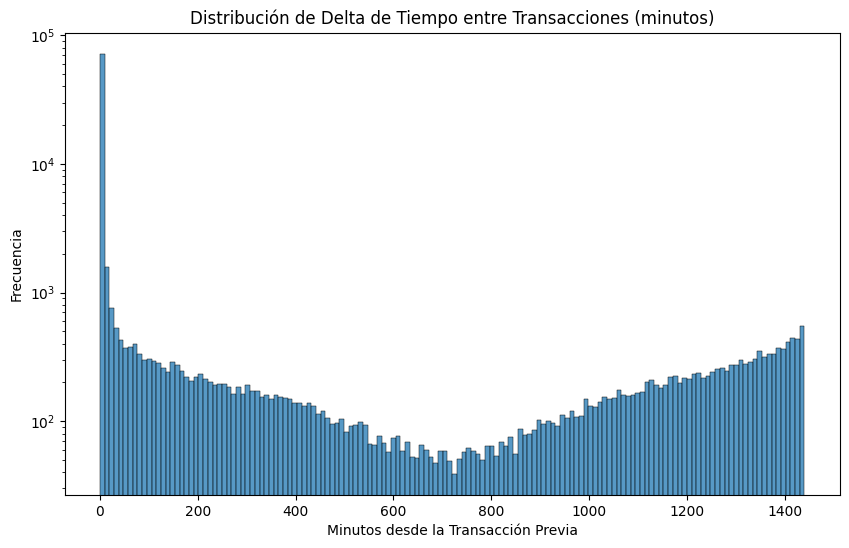

In [28]:
# Histograma de los deltas de tiempo (muestra para Seaborn si es muy grande)
plt.figure(figsize=(10, 6))
# Mantener como DataFrame hasta el final
data_for_plot = (
    df_transactions_with_delta.select("time_delta_minutes_to_prev_tx")
    .fill_null(0)
    .filter(pl.col("time_delta_minutes_to_prev_tx") < 1440)
    .sample(n=min(100000, df_transactions_with_delta.height))
    .to_pandas()["time_delta_minutes_to_prev_tx"]
)

sns.histplot(data_for_plot, bins=150)
plt.title("Distribución de Delta de Tiempo entre Transacciones (minutos)")
plt.xlabel("Minutos desde la Transacción Previa")
plt.ylabel("Frecuencia")
plt.yscale("log")
plt.show()

Esta segunda hipótesis se centra en el ritmo de las transacciones de un mismo usuario: la diferencia temporal entre ellas. El fraccionamiento implica transacciones realizadas en intervalos muy regulares o muy cortos.

La mayoría de las transacciones legítimas tendrán una distribución de delta de tiempo más dispersa. Un fraccionador podría generar un pico inusual y muy estrecho en valores bajos (alrededor de 1-5 minutos) si está realizando transacciones repetitivas de forma muy rápida. Si hay un volumen inusual de transacciones con deltas de tiempo muy cercanos a cero, esto es una fuerte señal de alarma.

En el gráfico de distribución del Delta de tiempo entre transacciones, vemos un pico en las primeras dos barras, que representan valores muy cercanos a cero; estos casos son sospechosos de fraccionamiento por la alta cantidad de transacciones en periodos de tiempo tan bajos.

El valle podría indicar que los deltas de tiempo "normales" de transacciones recurrentes (diarias) son más largos que la escala de minutos. El aumento hacia 1440 minutos muestra que muchas transacciones de un usuario ocurren con un delta de tiempo cercano a las 24 horas, lo cual es normal. El fraccionamiento busca precisamente evitar ser agrupado como un solo evento diario, a pesar de ocurrir en una ventana de 24 horas

# Conclusiones

Gracias al EDA, se ha identificado características claras que distinguen el comportamiento anómalo:

- Ráfagas de alta frecuencia: Múltiples transacciones en ventanas de tiempo cortas. 
- Uniformidad de montos: Transacciones con montos idénticos o muy similares.  Esto se captura perfectamente con la baja entropía y bajo coeficiente de variación.
- Proximidad temporal: Deltas de tiempo entre transacciones consecutivos inusualmente bajos.
